# Smartphone Impact & Addiction

Smartphone Impact & Addiction
This Google Colab workbook explores the intersection of digital behavior and personal wellbeing by analyzing how smartphone usage patterns influence stress, sleep, and performance. Using a variety of information visualizations, it identifies critical correlations between high device interaction—like excessive notifications and app opens—and their resulting impact on academic or work outcomes.

In [1]:
#Import Dependencies/Libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from holoviews.plotting.bokeh.styles import font_size

In [2]:
#Connect your Google Drive

In [3]:
#Upload your dataset
df = pd.read_csv('Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [5]:
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


### Data Cleaning
#### Plan:
- Drop ID columns
- Inspect structure, data types, null values and duplicates
- Fill null values
- Change strings to ordered categories where needed
- Add numeric encodings `stress_num` and `addiction_num` for correlation analysis
- Validate value ranges

In [6]:
# Drop ID columns
df.drop(columns=['transaction_id', 'user_id'], inplace=True)
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addiction_level', 'addicted_label']


In [7]:
# Inspect structure, data types, null values and duplicates
print('DATA TYPES')
print(df.dtypes)
print()
print('NULL VALUES')
print(df.isnull().sum())
print()
print('DUPLICATES')
print('Duplicate rows:', df.duplicated().sum())

DATA TYPES
age                          int64
gender                      object
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                object
academic_work_impact        object
addiction_level             object
addicted_label               int64
dtype: object

NULL VALUES
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

DUPLICATES
Duplicate row

In [8]:
df['addiction_level'].unique()

array([nan, 'Mild', 'Moderate', 'Severe'], dtype=object)

According to the dataset documentation in kaggle.com, `addiction_level` has 4 categories:
None, Mild, Moderate, Severe.

`None` was rendered as null values during import, so we have to fill null values with "None"


In [9]:
# Fill null values with 'None'
df['addiction_level'] = df['addiction_level'].fillna('None')

print(df['addiction_level'].isnull().sum())

0


`stress_level` (Low/Medium/High) and `addiction_level` (None/Mild/Moderate/Severe) are **ordinal.**

Leaving them as plain strings will plot them alphabetically instead of their logical order.

Numerical mapping was also added for correlation analysis later.

In [10]:
# Defining logical order for: stress_level; addiction_level
df['stress_level'] = pd.Categorical(df['stress_level'], categories=['Low', 'Medium', 'High'], ordered=True)
df['addiction_level'] = pd.Categorical(df['addiction_level'], categories=['None', 'Mild', 'Moderate', 'Severe'], ordered=True)

# Numeric encoding for correlation analysis
df['stress_num'] = df['stress_level'].map({'Low': 1, 'Medium': 2, 'High': 3})
df['addiction_num'] = df['addiction_level'].map({'None': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3})

print("Categorical ordering applied.")
print("Stress levels:", df['stress_level'].cat.categories.tolist())
print("Addiction levels:", df['addiction_level'].cat.categories.tolist())

Categorical ordering applied.
Stress levels: ['Low', 'Medium', 'High']
Addiction levels: ['None', 'Mild', 'Moderate', 'Severe']


In [11]:
# Validate value ranges
hour_columns = ['daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'weekend_screen_time']

print('Range Check')
for c in hour_columns:
    print(f'{c:<25} {df[c].min():.2f} to {df[c].max():.2f}')

print(f"Age Range: {df['age'].min()} to {df['age'].max()} years old")
print('Values are within reasonable range.')

Range Check
daily_screen_time_hours   3.00 to 12.00
social_media_hours        0.50 to 6.00
gaming_hours              0.00 to 4.00
work_study_hours          0.50 to 6.00
sleep_hours               4.50 to 9.00
weekend_screen_time       3.58 to 14.88
Age Range: 18 to 35 years old
Values are within reasonable range.


## Exploratory Data Analysis
- Distributions of numeric variables
- Counts of categorical variables
- Correlation matrix between numeric variables
- Faceted scatterplot between numeric variables

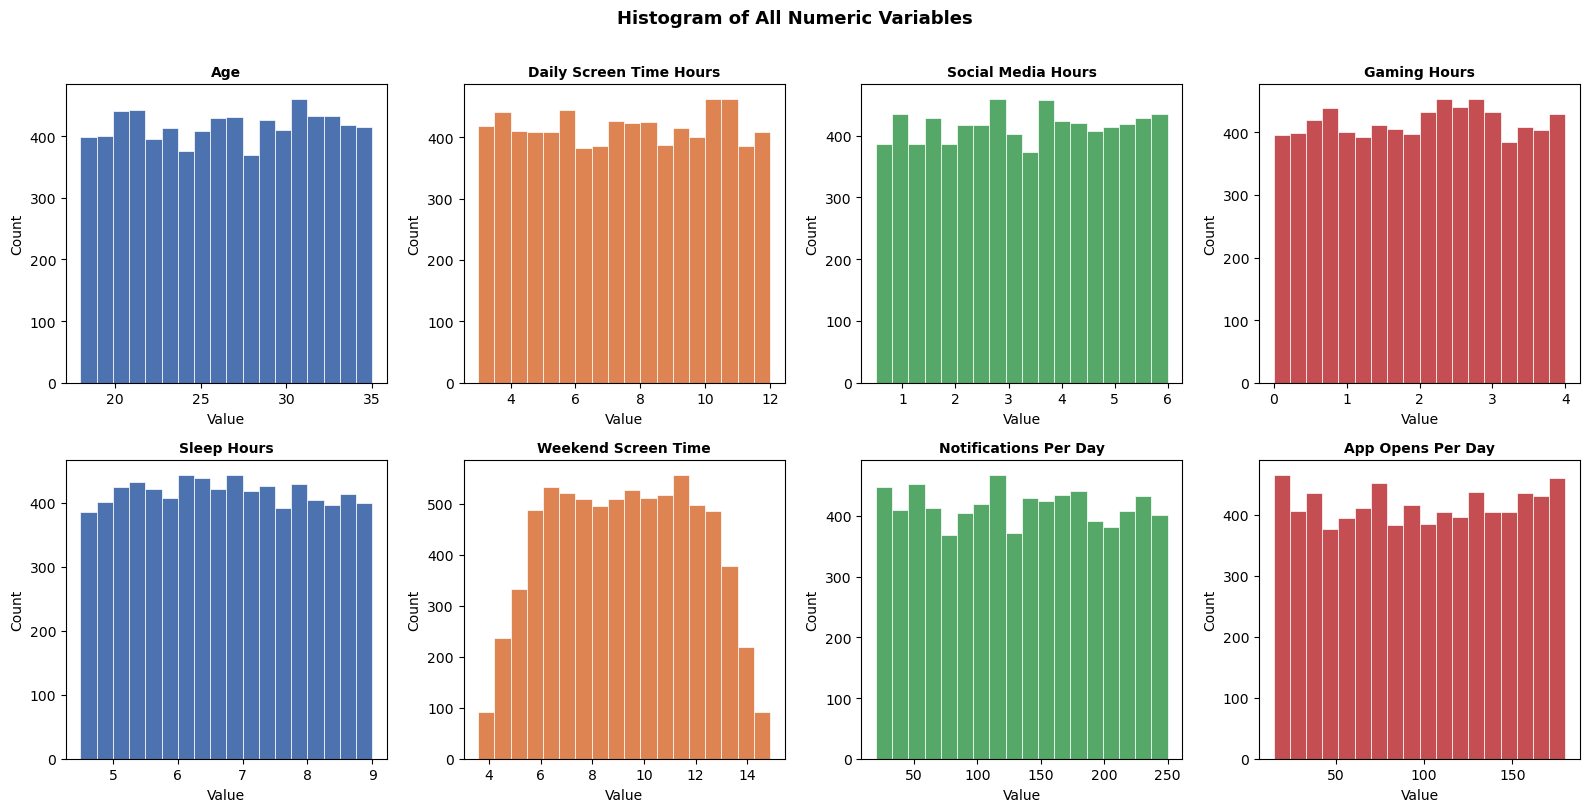

In [20]:
# Histograms of numeric columns
numeric_cols = ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'weekend_screen_time', 'notifications_per_day', 'app_opens_per_day']

fix, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=18, color=sns.color_palette('deep')[i%4], edgecolor='white', linewidth=0.5)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Histogram of All Numeric Variables', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

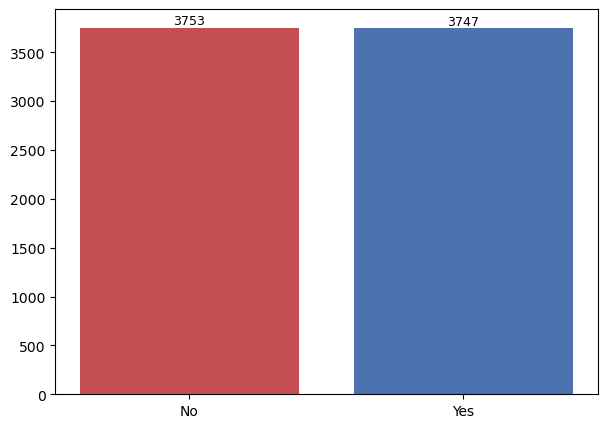

In [41]:
fig, ax = plt.subplots(figsize= (7, 5))
aw_impact_counts = df['academic_work_impact'].value_counts()
ax.bar(aw_impact_counts.index, aw_impact_counts.values, color=[sns.color_palette('deep')[3], sns.color_palette('deep')[0]])
for i, val in enumerate(aw_impact_counts.values):
    ax.text(i, val + 30, str(val), ha='center', fontsize=9)
ax.set_title('Academic/Work Impact')

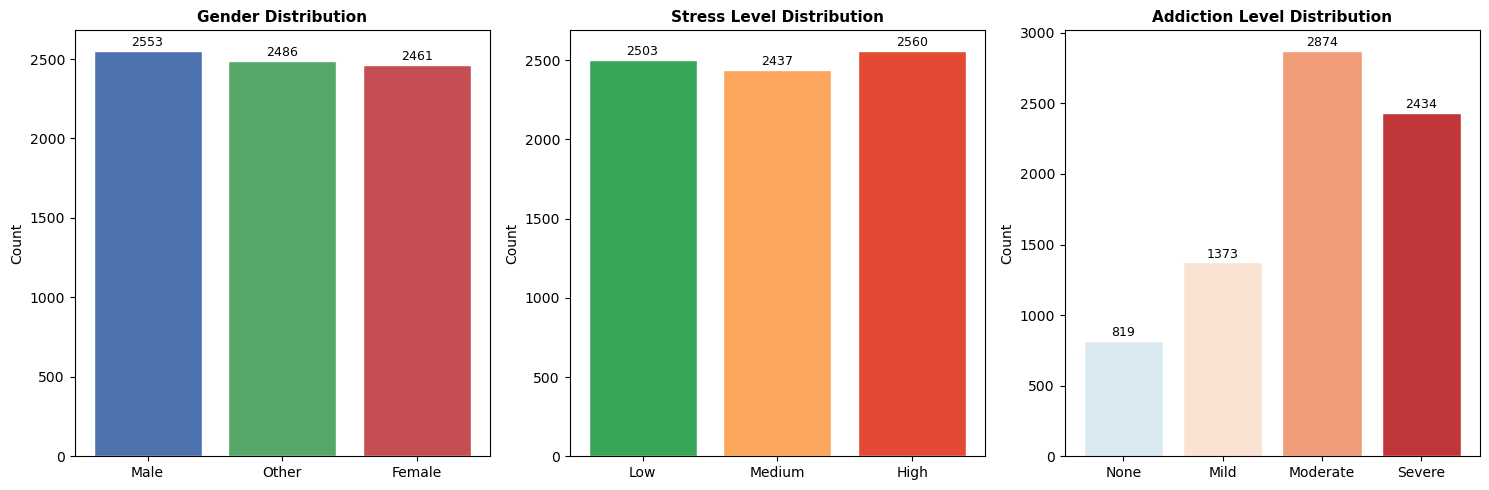

In [13]:
# Bar charts of catergorical variables
fig, axes = plt.subplots(1, 3, figsize=(15,5))

# Gender
gender_counts = df['gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=sns.color_palette('deep6', 3), edgecolor='white')
axes[0].set_title('Gender Distribution', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count')
for i, val in enumerate(gender_counts.values):
    axes[0].text(i, val + 30, str(val), ha='center', fontsize=9)

# Stress level
stress_order = ['Low', 'Medium', 'High']
stress_colors = [sns.color_palette('RdYlGn')[-1], sns.color_palette('RdYlGn')[1], sns.color_palette('RdYlGn')[0]]
stress_counts = df['stress_level'].value_counts()[stress_order]
axes[1].bar(stress_counts.index, stress_counts.values, color=stress_colors, edgecolor='white')
axes[1].set_title('Stress Level Distribution', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Count')
for i, val in enumerate(stress_counts.values):
    axes[1].text(i, val + 30, str(val), ha='center', fontsize=9)

# Addiction level
addiction_order = ['None', 'Mild', 'Moderate', 'Severe']
addiction_colors = [sns.color_palette('RdBu')[3], sns.color_palette('RdBu')[2], sns.color_palette('RdBu')[1], sns.color_palette('RdBu')[0]]
addiction_counts = df['addiction_level'].value_counts()[addiction_order]
axes[2].bar(addiction_counts.index, addiction_counts.values, color = addiction_colors, edgecolor='white')
axes[2].set_title('Addiction Level Distribution', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Count')
for i, val in enumerate(addiction_counts.values):
    axes[2].text(i, val + 30, str(val), ha='center', fontsize=9)\

plt.tight_layout()
plt.show()

In [17]:
df.columns.tolist()

['age',
 'gender',
 'daily_screen_time_hours',
 'social_media_hours',
 'gaming_hours',
 'work_study_hours',
 'sleep_hours',
 'notifications_per_day',
 'app_opens_per_day',
 'weekend_screen_time',
 'stress_level',
 'academic_work_impact',
 'addiction_level',
 'addicted_label',
 'stress_num',
 'addiction_num']

In [18]:
df.head()

,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,stress_num,addiction_num
0,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,None,0,2,0
1,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,None,0,2,0
2,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0,3,1
3,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1,3,2
4,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1,1,3


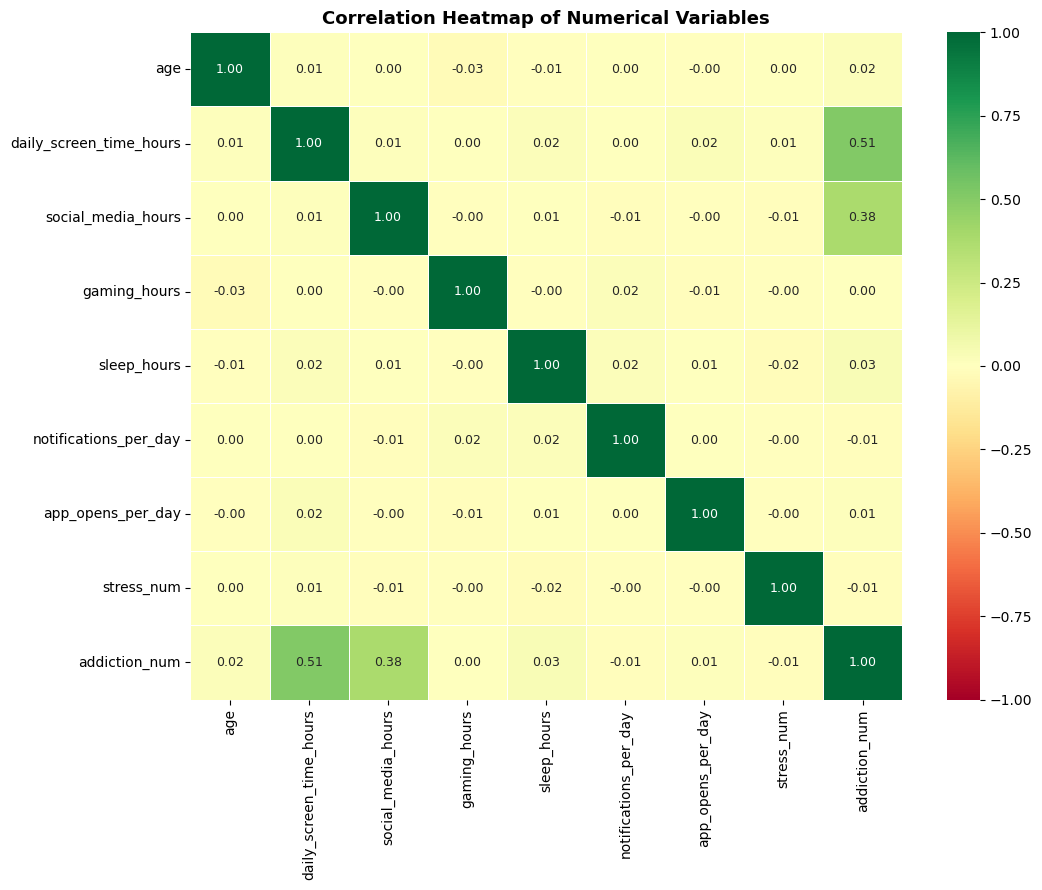

In [54]:
corr_cols = ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'stress_num', 'addiction_num']

# distributions are not normal; we use spearman method
corr_matrix = df[corr_cols].corr(method='spearman')

fix, ax = plt.subplots(figsize=(11, 9))
mask = pd.DataFrame(False, index=corr_matrix.index, columns=corr_matrix.columns)
for i in range(len(corr_matrix)):
    for j in range(i):
        mask.iloc[i, j] = True

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.5, ax=ax, vmin=-1, vmax=1, annot_kws={'size':9})
ax.set_title('Correlation Heatmap of Numerical Variables', fontsize=13, fontweight='bold')
plt.tight_layout()

## Findings and Insights (Conclusion)

Key Questions:(Please answer these questions using your data visualization)
1. Using a Histogram, what is the most common range of "Daily Screen Time" for the surveyed population?
2. Does an increase in daily notifications and screen time lead to a decrease in sleep duration and an increase in stress?
3. Do males and females show different "Addiction Classifications" or primary usage types (Gaming vs. Social Media)?
4. Is there a specific "Social Media Usage" hour count that consistently results in less than 6 hours of sleep?
5. As "Age" increases, does the "Smartphone Addiction Level" tend to decrease, suggesting a generational difference in usage?